Epoch [50/300] | Train Loss: 0.90101 | Val Loss: 0.83978
Epoch [100/300] | Train Loss: 0.71913 | Val Loss: 0.71358
Epoch [150/300] | Train Loss: 0.59763 | Val Loss: 0.66401
Epoch [200/300] | Train Loss: 0.50526 | Val Loss: 0.64533
Epoch [250/300] | Train Loss: 0.44163 | Val Loss: 0.62769
Epoch [300/300] | Train Loss: 0.38708 | Val Loss: 0.62243

<> In-Sample Performance <>
R2: 0.6180
Adj_R2: 0.6174
RMSE: 63.7395
MAE: 34.6459
ExplainedVar: 0.6181

<> Validation Performance (80/20) <>
R2: 0.3462
Adj_R2: 0.3417
RMSE: 80.8840
MAE: 41.8183
ExplainedVar: 0.3462


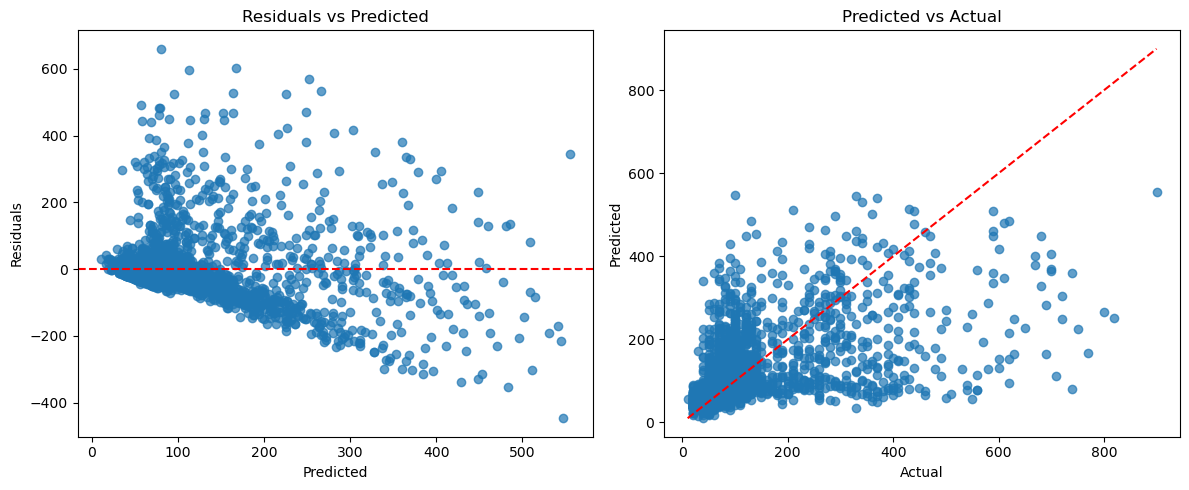

Epoch [50/150] | Train Loss: 0.90611 | Val Loss: 0.83575
Epoch [100/150] | Train Loss: 0.73321 | Val Loss: 0.72172
Epoch [150/150] | Train Loss: 0.60516 | Val Loss: 0.66024
Epoch [50/150] | Train Loss: 0.77674 | Val Loss: 0.92777
Epoch [100/150] | Train Loss: 0.65988 | Val Loss: 0.82215
Epoch [150/150] | Train Loss: 0.56161 | Val Loss: 0.76595
Epoch [50/150] | Train Loss: 0.90507 | Val Loss: 0.87996
Epoch [100/150] | Train Loss: 0.74475 | Val Loss: 0.74000
Epoch [150/150] | Train Loss: 0.60827 | Val Loss: 0.65877
Epoch [50/150] | Train Loss: 0.89140 | Val Loss: 0.86773
Epoch [100/150] | Train Loss: 0.74591 | Val Loss: 0.73876
Epoch [150/150] | Train Loss: 0.61810 | Val Loss: 0.65337
Epoch [50/150] | Train Loss: 0.90923 | Val Loss: 0.88046
Epoch [100/150] | Train Loss: 0.74882 | Val Loss: 0.73639
Epoch [150/150] | Train Loss: 0.61495 | Val Loss: 0.67342

<> 5-Fold Cross-Validation Average Metrics <>


{'R2': 0.31772193908691404,
 'Adj_R2': 0.313021375768554,
 'RMSE': 84.64887,
 'MAE': 44.89202,
 'ExplainedVar': 0.31872881650924684}

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42

df = pd.read_csv("energydata_complete.csv")
df = df.drop(columns=["date"])

y = df["Appliances"].values.reshape(-1, 1)
X = df.drop(columns=["Appliances"]).values
X = np.nan_to_num(X)
y = np.nan_to_num(y)
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

class EnergyModel(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32, 16, 8], activation='relu'):
        super(EnergyModel, self).__init__()
        act_fn = nn.ReLU() if activation == 'relu' else nn.Tanh()

        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn)
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))  # Output layer

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_model(model, X_train, y_train, X_val, y_val, epochs=300, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, y_val)
            print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {loss.item():.5f} | Val Loss: {val_loss.item():.5f}")

    return model

def regression_metrics(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - n_features - 1))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)
    return {"R2": r2, "Adj_R2": adj_r2, "RMSE": rmse, "MAE": mae, "ExplainedVar": evs}

input_dim = X_train.shape[1]
model = EnergyModel(input_dim, hidden_dims=[128, 64, 32, 16, 8], activation='relu').to(device)
trained_model = train_model(model, X_train, y_train, X_val, y_val, epochs=300, lr=0.001)

model.eval()
with torch.no_grad():
    y_train_pred = model(X_train).cpu().numpy()
    y_val_pred = model(X_val).cpu().numpy()

y_train_true = scaler_y.inverse_transform(y_train.cpu().numpy())
y_val_true = scaler_y.inverse_transform(y_val.cpu().numpy())
y_train_pred = scaler_y.inverse_transform(y_train_pred)
y_val_pred = scaler_y.inverse_transform(y_val_pred)

print("\n<> In-Sample Performance <>")
train_metrics = regression_metrics(y_train_true, y_train_pred, X_train.shape[1])
for k, v in train_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n<> Validation Performance (80/20) <>")
val_metrics = regression_metrics(y_val_true, y_val_pred, X_val.shape[1])
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

residuals = y_val_true.flatten() - y_val_pred.flatten()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_val_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

plt.subplot(1, 2, 2)
plt.scatter(y_val_true, y_val_pred, alpha=0.7)
plt.plot([y_val_true.min(), y_val_true.max()],
         [y_val_true.min(), y_val_true.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

def cross_validate(X, y, hidden_dims=[128, 64, 32, 16, 8], activation='relu', folds=5):
    kf = KFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)
    all_metrics = {"R2": [], "Adj_R2": [], "RMSE": [], "MAE": [], "ExplainedVar": []}

    for train_idx, test_idx in kf.split(X):
        X_train_fold = torch.tensor(X[train_idx], dtype=torch.float32).to(device)
        X_test_fold = torch.tensor(X[test_idx], dtype=torch.float32).to(device)
        y_train_fold = torch.tensor(y[train_idx], dtype=torch.float32).to(device)
        y_test_fold = torch.tensor(y[test_idx], dtype=torch.float32).to(device)

        model = EnergyModel(X.shape[1], hidden_dims, activation).to(device)
        train_model(model, X_train_fold, y_train_fold, X_test_fold, y_test_fold, epochs=150, lr=0.001)

        model.eval()
        with torch.no_grad():
            y_pred = model(X_test_fold).cpu().numpy()

        y_true = scaler_y.inverse_transform(y_test_fold.cpu().numpy())
        y_pred = scaler_y.inverse_transform(y_pred)
        metrics = regression_metrics(y_true, y_pred, X.shape[1])

        for k in all_metrics.keys():
            all_metrics[k].append(metrics[k])

    avg_metrics = {k: np.mean(v) for k, v in all_metrics.items()}
    print(f"\n<> {folds}-Fold Cross-Validation Average Metrics <>")
    return avg_metrics

cross_validate(X, y)